# Build a bulk-extraction regions table

Assembles the multi-row `regions_tsv` that `sv-evidence-extraction`'s
`build-tables` mode needs (columns `chrom`, `start`, `end`, `sample_id`
[comma-separated per family], `name`) -- the bulk analog of
`build_query_inputs.ipynb`'s single-event query inputs.

Pulls candidates from two sources, combined:

1. A table of follow-up regions to extract (schema TBD -- placeholder below).
2. A subset of `map_sv_folder`'s output (from the sibling `ASC_denovo_SV`
   repo's `sv_review_utils.py`) -- the same function that annotates
   reviewed SV image files with pedigree metadata.

This notebook currently stops right after the shared setup (config,
pedigree, cross-repo import), with placeholders for 1 and 2 -- fill
those in, then we combine them into one candidates table and generate
the final `regions_tsv`.


In [1]:
# ==========================================
# IMPORTS
# ==========================================
import json
import sys
from datetime import date
from pathlib import Path

import pandas as pd

from pedigree_utils import load_pedigree, resolve_family_sample_ids
from gcs_utils import upload_to_workspace_bucket

# sv_review_utils.py (map_sv_folder) lives in the sibling ASC_denovo_SV
# repo, not this one -- added via a path relative to this repo's root
# (assumed to be a sibling checkout under the same parent directory)
# rather than a hardcoded absolute path, so this still works if the
# whole python_code/ tree gets cloned somewhere else.
REPO_ROOT = Path.cwd().parent
ASC_DENOVO_SV_ROOT = REPO_ROOT.parent / "ASC_denovo_SV"
sys.path.insert(0, str(ASC_DENOVO_SV_ROOT))

from sv_review_utils import map_sv_folder


In [2]:
# ==========================================
# LOCAL CONFIG (workspace-specific paths)
# ==========================================
# Same gitignored local_config.json as the other notebooks -- see
# local_config.example.json for the expected shape.
LOCAL_CONFIG_PATH = REPO_ROOT / "local_config.json"

with open(LOCAL_CONFIG_PATH) as fh:
    local_config = json.load(fh)

local_config


{'evidence_paths_tsv': 'gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/SV_evidence_extraction/ASC_evidence_paths.tsv',
 'sample_batch_map_tsv': 'gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/sample_set_table/asd_cohort-sample_map-to_keep.tsv',
 'ped_file_uri': 'gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/SV_evidence_extraction/ped_ASC_WGS_basicQC_sex_check_relatednessV5_2025-08-29_forGATKSV.txt',
 'workspace_bucket': 'fc-secure-634cb4b1-313c-461f-b753-d647c49c9961',
 'upload_prefix': 'uploads/SV_evidence_extraction',
 'gcp_billing_project': 'talkowski-sv-gnomad',
 'local_evidence_dir': '/Users/murphyda/My Drive/SV_manual_plot_review/SV_evidence_extraction'}

In [3]:
# ==========================================
# PEDIGREE LOOKUP
# ==========================================
# Shared with build_query_inputs.ipynb / examine_evidence.ipynb via
# pedigree_utils.py, which itself now just re-exports from
# sv_evidence_extraction.pedigree (the copy that ships in the Docker
# image and is applied at extraction time).
df_ped = load_pedigree(local_config["ped_file_uri"])
df_ped.head()


/opt/anaconda3/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


,FamID,IndividualID,FatherID,MotherID,Gender,Affected
0,11000,__ssc02217__0cb03e,0,0,2,1.0
1,11000,__ssc02219__4ee3b0,0,0,1,1.0
2,11000,__ssc02220__b84587,__ssc02219__4ee3b0,__ssc02217__0cb03e,2,1.0
3,11000,__ssc02254__21f98a,__ssc02219__4ee3b0,__ssc02217__0cb03e,1,2.0
4,11001,__ss0013024__920359,__ssc02184__a8235a,__ssc02181__ddf9cb,1,2.0


## 1. Follow-up regions table

Placeholder -- exact source/schema TBD. At minimum this needs to end up
with columns identifying a chrom/start/end and the individual(s)
involved, so it can be normalized into the same shape as source 2
before the two are combined.


In [28]:
# ==========================================
# 1. LOAD FOLLOW-UP REGIONS TABLE
# ==========================================
# table pulled via firecloud.api, etc.) -- placeholder for now.
CPX_REVIEW_TABLE = '/Users/murphyda/My Drive/SV_manual_plot_review/Image_files/AF_0_1_plots_extended_PE/candidate_CPX_review_assignments_CA_DM.xlsx'
df_followup = pd.read_excel(CPX_REVIEW_TABLE)
df_followup


,candidate_cluster,image_file_names,reviewer,duplicated_INVs,is_CPX,new_label,comments,extract_coords
0,chr1_cluster0,asd_cohort.chr1.final_cleanup_DEL_chr1_260~~__...,Chiara,False,False,large_CNV/03_uncertain/01_breakpoints_off/03_b...,Three adjacent telomeric de novo DELs within 2...,chr1:914502-3505000
1,NaN,asd_cohort.chr1.final_cleanup_DEL_chr1_3083~~_...,Chiara,False,False,large_CNV/03_uncertain/01_breakpoints_off/03_b...,NaN,NaN
2,NaN,asd_cohort.chr1.final_cleanup_DEL_chr1_3349~~_...,Chiara,False,False,large_CNV/03_uncertain/01_breakpoints_off/03_b...,NaN,NaN
3,chr1_cluster1,asd_cohort.chr1.final_cleanup_DEL_chr1_11297~~...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/delINVdup,NaN,NaN
4,NaN,asd_cohort.chr1.final_cleanup_DUP_chr1_3970~~_...,Chiara,False,False,large_CNV/02_FP/02_duplicated_variant,NaN,NaN
...,...,...,...,...,...,...,...,...
275,overlaps_Belyeu/chr14_cluster7,asd_cohort.chr14.final_cleanup_DUP_chr14_5231~...,David,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/DUP_nDEL,"Three events, including poorly supported INS i...",chr14:102934871-105362229
276,overlaps_Belyeu/chr14_cluster7,asd_cohort.chr14.final_cleanup_DUP_chr14_5546~...,David,False,True,merge,NaN,NaN
277,overlaps_Belyeu/chr14_cluster7,asd_cohort.chr14.final_cleanup_INS_chr14_7032~...,David,False,True,merge,NaN,NaN
278,overlaps_Belyeu/chr16_cluster2,asd_cohort.chr16.final_cleanup_DUP_chr16_2874~...,David,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/DUP_nDEL,"Two events (0.28Mb, 1.45Mb gap, 0.97Mb) called...",chr16:24714500-27418528


## 2. Candidates from `map_sv_folder`

Placeholder -- run `map_sv_folder` against the real SV review image
root, then subset down to just the rows that should feed the bulk
extraction (e.g. by `svtype`, a manual `sv_id`/`vid` list, or whichever
filter makes sense here -- TBD).

Note: `map_sv_folder`'s own `IndividualID`/`FatherID`/`MotherID`
columns are the full evidence-pipeline-style IDs (matching this
cohort's PED file and `sample_batch_map_tsv`) -- its lowercase
`sample_id`/`father_id`/`mother_id` columns are a *different*,
shortened ID used for matching to SSC metadata, and are not what
`sv-evidence-extraction` expects.


In [5]:
# ==========================================
# 2. LOAD CANDIDATES FROM map_sv_folder
# ==========================================
# actually wanted for bulk extraction -- placeholders for now.
SV_REVIEW_ROOT = '/Users/murphyda/My Drive/SV_manual_plot_review/Image_files/AF_0_1_plots_extended_PE_20260911_CA'

df_sv = map_sv_folder(SV_REVIEW_ROOT, local_config["ped_file_uri"], skip_list=("NOT_FOUND_IN_SOURCE", "not_denovo"))
df_sv.head()


,fullpath,annotation,AF,sv_folder,name,svtype,sv_id,IndividualID,FamID,FatherID,...,Gender,Affected,father_id,mother_id,sample_id,chrom,pos,end,vid,svlen
0,/Users/murphyda/My Drive/SV_manual_plot_review...,candidate_CPX|chr4_cluster1,AF_0_1_plots,chr4_cluster1,asd_cohort.chr4.final_cleanup_INS_chr4_316~~__...,INS,INS_chr4_316,__sp0201668__b91821,SF0201667,__sp0201675__838b22,...,1,1.0,SP0201675,SP0201665,SP0201668,chr4,2755798,2755807,asd_cohort.chr4.final_cleanup_INS_chr4_316,9
1,/Users/murphyda/My Drive/SV_manual_plot_review...,candidate_CPX|chr4_cluster1,AF_0_1_plots,chr4_cluster1,asd_cohort.chr4.final_cleanup_INS_chr4_315~~__...,INS,INS_chr4_315,__sp0201668__b91821,SF0201667,__sp0201675__838b22,...,1,1.0,SP0201675,SP0201665,SP0201668,chr4,2755769,2755786,asd_cohort.chr4.final_cleanup_INS_chr4_315,17
2,/Users/murphyda/My Drive/SV_manual_plot_review...,candidate_CPX|chr5_cluster6,AF_0_1_plots,chr5_cluster6,asd_cohort.chr5.final_cleanup_DEL_chr5_25440~~...,DEL,DEL_chr5_25440,__sp0336341__f05ac2,SF0336341,__sp0336344__eb2569,...,1,2.0,SP0336344,SP0336338,SP0336341,chr5,131036444,131038451,asd_cohort.chr5.final_cleanup_DEL_chr5_25440,2007
3,/Users/murphyda/My Drive/SV_manual_plot_review...,candidate_CPX|chr5_cluster6,AF_0_1_plots,chr5_cluster6,asd_cohort.chr5.final_cleanup_DEL_chr5_25439~~...,DEL,DEL_chr5_25439,__sp0336341__f05ac2,SF0336341,__sp0336344__eb2569,...,1,2.0,SP0336344,SP0336338,SP0336341,chr5,131036431,131038451,asd_cohort.chr5.final_cleanup_DEL_chr5_25439,2020
4,/Users/murphyda/My Drive/SV_manual_plot_review...,candidate_CPX|chr4_cluster6,AF_0_1_plots,chr4_cluster6,asd_cohort.chr4.final_cleanup_DEL_chr4_22427~~...,DEL,DEL_chr4_22427,__sp0070310__18c62f,SF0070310,__sp0071476__62a9ef,...,1,2.0,SP0071476,SP0070309,SP0070310,chr4,109598084,109598164,asd_cohort.chr4.final_cleanup_DEL_chr4_22427,80


## 3. Combine both sources into one candidates table

Normalizes both sources to the same shape (`chrom`, `start`, `end`,
`sample_id`, `name`) and concatenates them -- this becomes the input to
the final `regions_tsv`-writing step.

Two real data issues found and handled here (confirmed by hand against
the actual files, not assumed):

- `image_file_names` in the review table is inconsistent about whether
  it already ends in ".png" -- blindly appending ".png" to join against
  `df_sv["name"]` missed ~65% of real matches (it produced "*.png.png"
  for rows that already had the extension). Stripping ".png" from both
  sides before comparing fixes this.
- A handful of `extract_coords` values have a stray trailing character
  after the end coordinate (e.g. "chr19:21573869-21574019.") --
  stripped defensively in `region_from_extract_coords`.
- `sv_id` is not globally unique across individuals -- two *different*
  families can share the same `sv_id` at the same coordinates. Their
  `name` is disambiguated by appending `IndividualID`.


In [6]:
# ==========================================
# PARSE extract_coords
# ==========================================
import re


def region_from_extract_coords(extract_coords):
    """Parse a "chrom:start-end" extract_coords string into (chrom, start, end).

    Parameters
    ----------
    extract_coords : str
        e.g. "chr1:914502-3505000". A handful of manually-entered values
        in the review table have a stray trailing character (e.g. a
        period) after the end coordinate, stripped here defensively
        rather than left to raise deep inside int().

    Returns
    -------
    tuple of (str, int, int)
        chrom, start, end.
    """
    chrom, span = extract_coords.split(":")
    start_str, end_str = span.split("-")
    end_str = re.sub(r"[^0-9]", "", end_str)
    return chrom, int(start_str), int(end_str)


In [7]:
# ==========================================
# 3a. FOLLOW-UP TABLE ROWS -> NORMALIZED CANDIDATES
# ==========================================
# Only rows with a designated extraction region are used (a cluster's
# other constituent-call rows, without their own extract_coords, are
# skipped -- extract_coords marks the one row per cluster that carries
# the actual region to pull).
df_followup_todo = df_followup[df_followup["extract_coords"].notna()].copy()

# name_noext / image_file_noext are the stable join key -- normalize
# both sides before joining (see note above on the inconsistent ".png"
# suffix). Pulling "sv_id" over from df_sv here (not just IndividualID)
# lets these rows use the exact same {sv_id}_{sample_id} name
# convention as the uncertain-folder rows below, instead of
# candidate_cluster.
df_sv["name_noext"] = df_sv["name"].str.replace(".png", "", regex=False)
df_followup_todo["image_file_noext"] = (
    df_followup_todo["image_file_names"].str.replace(".png", "", regex=False)
)

followup_joined = df_followup_todo.merge(
    df_sv[["name_noext", "IndividualID", "sv_id"]],
    left_on="image_file_noext", right_on="name_noext", how="left",
)

# Surface any join misses loudly rather than silently dropping candidates.
unmatched = followup_joined[followup_joined["IndividualID"].isna()]
if len(unmatched):
    print(f"WARNING: {len(unmatched)} follow-up row(s) had no filename match in df_sv -- dropped:")
    print(unmatched[["candidate_cluster", "image_file_names"]].to_string())

followup_rows = []
for _, row in followup_joined.dropna(subset=["IndividualID"]).iterrows():
    chrom, start, end = region_from_extract_coords(row["extract_coords"])
    sample_ids = resolve_family_sample_ids(row["IndividualID"], df_ped, include="both")
    followup_rows.append({
        "chrom": chrom, "start": start, "end": end,
        "sample_id": ",".join(sample_ids), "name": f"{row['sv_id']}_{row['IndividualID']}",
    })

print(f"{len(followup_rows)} candidates from the follow-up table")


34 candidates from the follow-up table


In [8]:
# ==========================================
# 3b. df_sv "uncertain" ROWS -> NORMALIZED CANDIDATES
# ==========================================
df_uncertain = df_sv[df_sv["annotation"].str.contains("uncertain")]

uncertain_rows = []
for _, row in df_uncertain.iterrows():
    sample_ids = resolve_family_sample_ids(row["IndividualID"], df_ped, include="both")
    # sv_id isn't globally unique across individuals (confirmed: two
    # different families can share the same sv_id/coordinates), so
    # IndividualID is appended to keep `name` unique.
    uncertain_rows.append({
        "chrom": row["chrom"], "start": int(row["pos"]), "end": int(row["end"]),
        "sample_id": ",".join(sample_ids), "name": f"{row['sv_id']}_{row['IndividualID']}",
    })

print(f"{len(uncertain_rows)} candidates from the uncertain-folder rows")


87 candidates from the uncertain-folder rows


In [9]:
# ==========================================
# 3c. COMBINE
# ==========================================
df_candidates = pd.DataFrame(followup_rows + uncertain_rows)

assert df_candidates["name"].is_unique, "duplicate candidate names -- regions_tsv rows must be distinguishable"
assert df_candidates.isna().sum().sum() == 0, "unexpected nulls in the combined candidates table"

# Informational only -- RD extraction needs the full padded span, so a
# very large region means a correspondingly large bincov slice (e.g.
# ~300k bins x 3 samples for a 30Mb region). Most "large_CNV"-track
# candidates are expected to be multi-Mb and are fine; this is just a
# visibility check, not a filter, so an outlier doesn't slip through
# unnoticed the way INV_chr8_86 initially did below.
LARGE_REGION_THRESHOLD = 5_000_000
large = df_candidates[(df_candidates["end"] - df_candidates["start"]) > LARGE_REGION_THRESHOLD]
if len(large):
    print(f"NOTE: {len(large)} candidate(s) over {LARGE_REGION_THRESHOLD:,}bp (informational only):")
    print(large[["name", "chrom", "start", "end"]].assign(span=large["end"] - large["start"]).to_string())

# Explicit, visible exclusions -- both of these are extreme-size INV
# calls (~18-30Mb) set aside for separate one-off review rather than
# run through the bulk table; confirmed these are real filename-encoded
# coordinates, not a parsing bug, before deciding to exclude them.
EXCLUDE_NAMES = ["INV_chr8_86___sp0221640__9900be", "INV_chr12_78___sp0141692__379904"]
before = len(df_candidates)
df_candidates = df_candidates[~df_candidates["name"].isin(EXCLUDE_NAMES)].reset_index(drop=True)
print(f"\nexcluded {before - len(df_candidates)} row(s) via EXCLUDE_NAMES; {len(df_candidates)} remain")

print(f"\n{len(followup_rows)} follow-up + {len(uncertain_rows)} uncertain, {before - len(df_candidates)} excluded -> {len(df_candidates)} total candidates")
df_candidates


NOTE: 14 candidate(s) over 5,000,000bp (informational only):
                                          name  chrom      start        end      span
16             DEL_chr18_1___bk_381_03__175dab  chr18       9998    7944000   7934002
24           DEL_chr1_25068___ssc07343__a668bc   chr1   93078692  112981398  19902706
56            DUP_chr1_4039___ssc03276__285808   chr1   29721834   35841835   6120001
61          DUP_chr19_5835___sp0213241__4a9ad8  chr19   47914873   58607400  10692527
62              DUP_chr3_1___sp0075868__8a3e5b   chr3       9998   48921400  48911402
68   DUP_chr12_7161___2_0278_003_recal__b05cf0  chr12  113044127  133260000  20215873
71   DEL_chr7_36585___1_0383_003_recal__1615d1   chr7  151532803  159335800   7802997
86           DEL_chr9_11254___ssc11356__32886d   chr9   65891190   76306600  10415410
103         DUP_chr16_1225___sp0148955__218396  chr16    7007999   30226486  23218487
105         DEL_chr4_31295___sp0149275__83b865   chr4  163499380  174705700  11

,chrom,start,end,sample_id,name
0,chr1,914502,3505000,"__asd_1841__fcabd1,__hfa17_2__35d01b,__asd_180...",DEL_chr1_260___asd_1841__fcabd1
1,chr1,28236100,28238071,"__2_1749_003_recal__fe78ae,__2_1749_002_recal_...",DEL_chr1_11772___2_1749_003_recal__fe78ae
2,chr1,99663949,99675874,"__sp0241708__8e2cd3,__sp0251054__6b75b1,__sp02...",DEL_chr1_26065___sp0241708__8e2cd3
3,chr2,165283617,168115618,"__mssng00227_003_recal__7ed400,__mssng00227_00...",DEL_chr2_34983___mssng00227_003_recal__7ed400
4,chr2,235898198,235945418,"__sp0155140__fa7feb,__sp0155189__1a7e6d,__sp01...",DEL_chr2_48493___sp0155140__fa7feb
...,...,...,...,...,...
114,chr12,689999,700000,"__05c47390__709e86,__05c47387__724727,__05c473...",DUP_chr12_150___05c47390__709e86
115,chr14,70402893,70810167,"__03c14371__cd231a,__03c16142__2b7949,__03c161...",DUP_chr14_2962___03c14371__cd231a
116,chr12,197999,208000,"__bel_67_4__54f90b,__bel_67_1__195721,__bel_67...",DUP_chr12_42___bel_67_4__54f90b
117,chr4,182621380,184120000,"__ssc12148__fb0799,__ssc12147__a438bd,__ssc121...",DUP_chr4_9734___ssc12148__fb0799


## 4. Write and upload the regions_tsv

Writes `df_candidates` out in the exact schema
`sv_evidence_extraction.core.load_regions_table` expects (`chrom`,
`start`, `end`, `sample_id`, `name`), then uploads it to the workspace
bucket the same way `build_query_inputs.ipynb` does for a single query.


In [10]:
# ==========================================
# WRITE THE regions_tsv
# ==========================================
def write_regions_tsv(df_candidates, out_path):
    """Write a combined candidates table to a build-tables regions_tsv.

    Parameters
    ----------
    df_candidates : pandas.DataFrame
        Must have columns "chrom", "start", "end", "sample_id", "name"
        -- matches sv_evidence_extraction.core.load_regions_table's
        expected schema exactly.
    out_path : str or pathlib.Path
        Where to write the TSV.

    Returns
    -------
    pathlib.Path
        `out_path`, for chaining into the upload step.
    """
    required = {"chrom", "start", "end", "sample_id", "name"}
    missing = required - set(df_candidates.columns)
    if missing:
        raise ValueError(f"df_candidates is missing required columns: {sorted(missing)}")

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df_candidates[["chrom", "start", "end", "sample_id", "name"]].to_csv(out_path, sep="\t", index=False)
    return out_path


In [11]:
# ==========================================
# WRITE + UPLOAD
# ==========================================
# Date-stamped (matching this project's existing file-naming convention,
# e.g. the pedigree file's own dated name) so re-running on a different
# day after further edits doesn't silently overwrite an earlier version.
out_path = REPO_ROOT / "notebooks" / "generated" / f"bulk_regions_{date.today():%Y%m%d}.tsv"
write_regions_tsv(df_candidates, out_path)
print(f"Wrote {out_path}")

# Captured (not just called for its printed side effect) -- section 5
# below needs this gs:// URI to point Cromwell at the regions_tsv,
# the same way evidence_paths_tsv/sample_batch_map_tsv/ped_file are
# already real gs:// paths rather than local filesystem paths.
regions_tsv_uri = upload_to_workspace_bucket(
    local_path=out_path,
    workspace_bucket=local_config["workspace_bucket"],
    upload_prefix=local_config["upload_prefix"],
    gcp_billing_project=local_config["gcp_billing_project"],
)


Wrote /Users/murphyda/My Drive/python_code/sv-evidence-extraction/notebooks/generated/bulk_regions_20260915.tsv


/opt/anaconda3/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
I0915 15:35:06.512436 6995652 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0915 15:35:06.516555 6995935 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(80, generation: 1)


Uploaded to gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/SV_evidence_extraction/bulk_regions_20260915.tsv


## 5. Build `build_tables.inputs.json`

Bulk analog of `build_query_inputs.ipynb`'s query-mode inputs step:
merges the stable defaults in
[`inputs/build_tables.inputs.json`](../inputs/build_tables.inputs.json)
(evidence-paths table, sample/batch map, docker image, padding) with
the two things that vary for this run -- the `regions_tsv` gs:// URI
just uploaded in section 4, and an `output_prefix` labeling this
batch's shared pe/sr/rd output tables -- to produce a ready-to-submit
Terra input JSON.


In [12]:
# ==========================================
# BUILD build_tables.inputs.json
# ==========================================
def write_build_tables_inputs_json(regions_tsv_uri, output_prefix, local_config, template_path, out_path):
    """Merge the bulk regions_tsv location and a run label into the build-tables input template.

    Mirrors `build_query_inputs.ipynb`'s `write_query_inputs_json`, but
    for build-tables mode: there's no per-event region/sample_ids to
    compute here, since that scoping already lives inside the
    regions_tsv itself (one row per candidate, each naming its own
    sample_id(s) -- see sections 1-4 above). All this needs to do is
    point Cromwell at that file (as a real gs:// URI, since File
    inputs must be Cromwell-localizable -- a local path won't work)
    and give the run's shared output tables a name.

    Parameters
    ----------
    regions_tsv_uri : str
        gs:// URI of the regions_tsv already uploaded to the workspace
        bucket in section 4 above.
    output_prefix : str
        Label for this batch's output files -- becomes the
        "{output_prefix}.pe.tsv" / ".sr.tsv" / ".rd.tsv" (and .parquet)
        filenames that BuildEvidenceTables writes for the *entire*
        regions_tsv in one shared set of tables (unlike query mode,
        which produces one set of tables per single event).
    local_config : dict
        As loaded from local_config.json -- supplies
        evidence_paths_tsv, sample_batch_map_tsv, and ped_file_uri,
        the same stable inputs every mode/run in this repo shares.
    template_path : str or pathlib.Path
        Path to the checked-in inputs/build_tables.inputs.json
        (structural template: key names, padding defaults, docker
        image) -- nothing workspace- or run-specific is hardcoded
        here, matching this repo's local_config.json convention.
    out_path : str or pathlib.Path
        Where to write the merged, ready-to-submit JSON.

    Returns
    -------
    dict
        The merged input dictionary that was written to `out_path`.
    """
    with open(template_path) as fh:
        merged = json.load(fh)

    merged["SVEvidenceExtraction.evidence_paths_tsv"] = local_config["evidence_paths_tsv"]
    merged["SVEvidenceExtraction.sample_batch_map_tsv"] = local_config["sample_batch_map_tsv"]
    merged["SVEvidenceExtraction.ped_file"] = local_config["ped_file_uri"]
    merged["SVEvidenceExtraction.regions_tsv"] = regions_tsv_uri
    merged["SVEvidenceExtraction.output_prefix"] = output_prefix

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as fh:
        json.dump(merged, fh, indent=2)

    return merged


In [13]:
# ==========================================
# WRITE + UPLOAD build_tables.inputs.json
# ==========================================
# Reuses the same date stamp as the regions_tsv written in section 4,
# so the two files a given run produces (regions_tsv + its inputs
# json) stay visibly paired by name.
output_prefix = f"bulk_extraction_{date.today():%Y%m%d}"

inputs_out_path = REPO_ROOT / "notebooks" / "generated" / f"{output_prefix}.build_tables.inputs.json"
merged_inputs = write_build_tables_inputs_json(
    regions_tsv_uri=regions_tsv_uri,
    output_prefix=output_prefix,
    local_config=local_config,
    template_path=REPO_ROOT / "inputs" / "build_tables.inputs.json",
    out_path=inputs_out_path,
)
print(f"Wrote {inputs_out_path}")

upload_to_workspace_bucket(
    local_path=inputs_out_path,
    workspace_bucket=local_config["workspace_bucket"],
    upload_prefix=local_config["upload_prefix"],
    gcp_billing_project=local_config["gcp_billing_project"],
)

merged_inputs


Wrote /Users/murphyda/My Drive/python_code/sv-evidence-extraction/notebooks/generated/bulk_extraction_20260915.build_tables.inputs.json


/opt/anaconda3/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
I0915 15:35:07.407457 6995652 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0915 15:35:07.414131 6996014 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(80, generation: 1)


Uploaded to gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/SV_evidence_extraction/bulk_extraction_20260915.build_tables.inputs.json


{'SVEvidenceExtraction.mode': 'build_tables',
 'SVEvidenceExtraction.evidence_paths_tsv': 'gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/SV_evidence_extraction/ASC_evidence_paths.tsv',
 'SVEvidenceExtraction.sample_batch_map_tsv': 'gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/sample_set_table/asd_cohort-sample_map-to_keep.tsv',
 'SVEvidenceExtraction.ped_file': 'gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/SV_evidence_extraction/ped_ASC_WGS_basicQC_sex_check_relatednessV5_2025-08-29_forGATKSV.txt',
 'SVEvidenceExtraction.regions_tsv': 'gs://fc-secure-634cb4b1-313c-461f-b753-d647c49c9961/uploads/SV_evidence_extraction/bulk_regions_20260915.tsv',
 'SVEvidenceExtraction.output_prefix': 'bulk_extraction_20260915',
 'SVEvidenceExtraction.pad_pct': 0.3,
 'SVEvidenceExtraction.pad_floor': 1000,
 'SVEvidenceExtraction.pad_ceiling_pe_sr': 5000,
 'SVEvidenceExtraction.docker': 'us.gcr.io/talkowski-sv-gnomad/dam/sv-evidence-extraction:latest',
 'SVEvide

In [32]:
df_sv.shape

(4697, 22)

In [22]:
df_sv[df_sv.annotation.str.contains('05_CPX')]

,fullpath,annotation,AF,sv_folder,name,svtype,sv_id,IndividualID,FamID,FatherID,...,Affected,father_id,mother_id,sample_id,chrom,pos,end,vid,svlen,name_noext
3358,/Users/murphyda/My Drive/SV_manual_plot_review...,small_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,02_paternal,asd_cohort.chr12.final_cleanup_DUP_chr12_5241~...,DUP,DUP_chr12_5241,__au14101a_91789415__96a71a,AU14100,__au14105a_1050793371__d830e2,...,2.0,AU14105A_1050793371,AU14104A_1050793346,AU14101A_91789415,chr12,78511886,78514805,asd_cohort.chr12.final_cleanup_DUP_chr12_5241,2919,asd_cohort.chr12.final_cleanup_DUP_chr12_5241~...
3359,/Users/murphyda/My Drive/SV_manual_plot_review...,small_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,01_maternal,asd_cohort.chr20.final_cleanup_DEL_chr20_8601~...,DEL,DEL_chr20_8601,__2_1738_003_recal__661056,FAM_2-1738-001,__2_1738_002_recal__b3dabd,...,2.0,2_1738_002_RECAL,2_1738_001_RECAL,2_1738_003_RECAL,chr20,38104076,38108227,asd_cohort.chr20.final_cleanup_DEL_chr20_8601,4151,asd_cohort.chr20.final_cleanup_DEL_chr20_8601~...
3360,/Users/murphyda/My Drive/SV_manual_plot_review...,small_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,02_full_siblings,asd_cohort.chr3.final_cleanup_DUP_chr3_3760~~_...,DUP,DUP_chr3_3760,__ssc02677__e044aa,11284,__ssc02702__683c9e,...,2.0,SSC02702,SSC02688,SSC02677,chr3,62073638,62076815,asd_cohort.chr3.final_cleanup_DUP_chr3_3760,3177,asd_cohort.chr3.final_cleanup_DUP_chr3_3760~~_...
3361,/Users/murphyda/My Drive/SV_manual_plot_review...,small_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,02_full_siblings,asd_cohort.chr3.final_cleanup_DUP_chr3_3760~~_...,DUP,DUP_chr3_3760,__ssc02703__d1f065,11284,__ssc02702__683c9e,...,1.0,SSC02702,SSC02688,SSC02703,chr3,62073638,62076815,asd_cohort.chr3.final_cleanup_DUP_chr3_3760,3177,asd_cohort.chr3.final_cleanup_DUP_chr3_3760~~_...
4385,/Users/murphyda/My Drive/SV_manual_plot_review...,large_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,05_CPX,asd_cohort.chrX.final_cleanup_DUP_chrX_5264~~_...,DUP,DUP_chrX_5264,__ssc12199__f27456,14573,__ssc12198__154e08,...,1.0,SSC12198,SSC12195,SSC12199,chrX,52132963,52161000,asd_cohort.chrX.final_cleanup_DUP_chrX_5264,28037,asd_cohort.chrX.final_cleanup_DUP_chrX_5264~~_...
4386,/Users/murphyda/My Drive/SV_manual_plot_review...,large_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,02_full_siblings,asd_cohort.chr14.final_cleanup_DUP_chr14_1288~...,DUP,DUP_chr14_1288,__kor_321_04__a8fc4d,KOR-321,__kor_321_01__851a07,...,1.0,KOR_321_01,KOR_321_02,KOR_321_04,chr14,39583636,39599713,asd_cohort.chr14.final_cleanup_DUP_chr14_1288,16077,asd_cohort.chr14.final_cleanup_DUP_chr14_1288~...
4387,/Users/murphyda/My Drive/SV_manual_plot_review...,large_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,02_full_siblings,asd_cohort.chr14.final_cleanup_DUP_chr14_1288~...,DUP,DUP_chr14_1288,__kor_321_03__53fa58,KOR-321,__kor_321_01__851a07,...,2.0,KOR_321_01,KOR_321_02,KOR_321_03,chr14,39583636,39599713,asd_cohort.chr14.final_cleanup_DUP_chr14_1288,16077,asd_cohort.chr14.final_cleanup_DUP_chr14_1288~...
4388,/Users/murphyda/My Drive/SV_manual_plot_review...,large_CNV|02_FP|01_inherited|07_wrong_SV_type|...,AF_0_1_plots,01_maternal,asd_cohort.chr11.final_cleanup_DUP_chr11_7209~...,DUP,DUP_chr11_7209,__10c114748__d2d7cd,AU3787,__10c114767__9637ab,...,1.0,10C114767,10C114749,10C114748,chr11,100648489,100679718,asd_cohort.chr11.final_cleanup_DUP_chr11_7209,31229,asd_cohort.chr11.final_cleanup_DUP_chr11_7209~...
4673,/Users/murphyda/My Drive/SV_manual_plot_review...,large_CNV|02_FP|01_inherited|02_paternal|05_CP...,AF_0_1_plots,invertedDUP,asd_cohort.chr4.final_cleanup_DUP_chr4_4854~~_...,DUP,DUP_chr4_4854,__kor_307_03__ca7a57,KOR-307,__kor_307_01__fb0857,...,2.0,KOR_307_01,KOR_307_02,KOR_307_03,chr4,75785380,76061381,asd_cohort.chr4.final_cleanup_DUP_chr4_4854,276001,asd_cohort.chr4.final_cleanup_DUP_chr4_4854~~_...
4674,/Users/murphyda/My Drive/SV_manual_plot_review...,large_CNV

In [30]:
df_followup[df_followup.new_label.str.contains('05_CPX')]

,candidate_cluster,image_file_names,reviewer,duplicated_INVs,is_CPX,new_label,comments,extract_coords
3,chr1_cluster1,asd_cohort.chr1.final_cleanup_DEL_chr1_11297~~...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/delINVdup,NaN,NaN
9,chr1_cluster6,asd_cohort.chr1.final_cleanup_DEL_chr1_26065~~...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/adjace...,Two de novo DELs separated by 684 bp; Looks li...,chr1:99663949-99675874
26,NaN,asd_cohort.chr2.final_cleanup_DEL_chr2_48493~~...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/adjace...,Two adjacent small/large de novo DELs 5kb apart,chr2:235898198-235945418
31,chr3_cluster3,asd_cohort.chr3.final_cleanup_DEL_chr3_6831~~_...,Chiara,False,True,small_CNV/01_TP/07_wrong_SV_type/05_CPX/proces...,Four adjacent de novo small DELs within 58kb; ...,chr3:32996617-33097146
38,NaN,asd_cohort.chr3.final_cleanup_DEL_chr3_12675~~...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/adjace...,NaN,NaN
80,chr5_cluster8,asd_cohort.chr5.final_cleanup_DUP_chr5_10190~~...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/dupINVdel,NaN,NaN
99,NaN,asd_cohort.chr7.final_cleanup_DUP_chr7_7813~~_...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/DUP_pDEL,NaN,NaN
112,chr8_cluster2,asd_cohort.chr8.final_cleanup_DEL_chr8_19739~~...,Chiara,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/adjace...,One PE pair is missing for adjacentDEL,NaN
129,chr11_cluster1,asd_cohort.chr11.final_cleanup_DUP_chr11_2244~...,David,False,True,large_CNV/01_TP/07_wrong_SV_type/05_CPX/dDUP,NaN,NaN
134,chr11_cluster4,asd_cohort.chr11.final_cleanup_DEL_chr11_10452...,David,False,True,small_CNV/01_TP/07_wrong_SV_type/05_CPX/adjace...,Two small DELs part of the same event,NaN


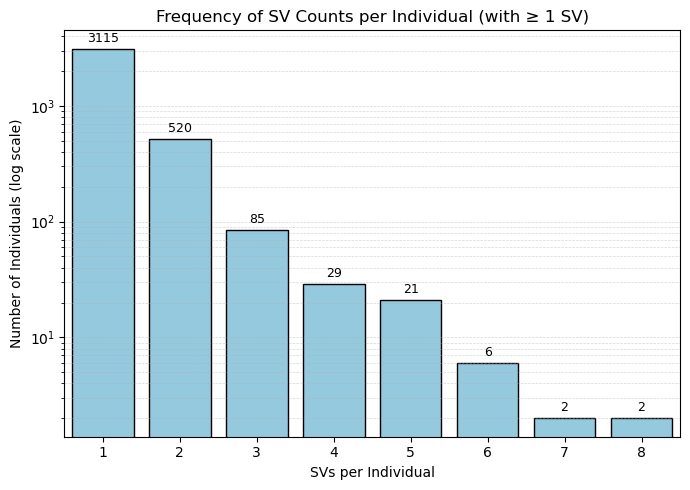

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count SVs per individual, then count frequency of each discrete total
sv_per_ind_counts = df_sv["IndividualID"].value_counts().value_counts().sort_index()

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=sv_per_ind_counts.index, y=sv_per_ind_counts.values, color="skyblue", edgecolor="black")

# Log scale for discrete count frequency
plt.yscale("log")

plt.xlabel("SVs per Individual")
plt.ylabel("Number of Individuals (log scale)")
plt.title("Frequency of SV Counts per Individual (with ≥ 1 SV)")
plt.grid(axis="y", which="both", ls="--", alpha=0.5)

# Annotate exact individual counts on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha="center", va="bottom", xytext=(0, 3),
                    textcoords="offset points", fontsize=9)

plt.tight_layout()
plt.show()